---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [85]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Loading the Four Data Files

In [86]:
# Load each .csv into a dataframe
df_sessions = pd.read_csv("data/sessions.csv")
df_streamers = pd.read_csv("data/streamers.csv")
df_streams = pd.read_csv("data/streams.csv")
df_viewers = pd.read_csv("data/viewers.csv")

Each .csv file is loaded into its own DataFrame.

### sessions.csv

*Columns*

- *session_id*: **Numerical**
    - the id of the session a viewer watches a stream (the id starts with SES) (string)
- *viewer_id*: **Numerical**
    - the id of the viewer (the id starts with VWR) (string)
- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *stream_id*: **Numerical**
    - the id of the stream (the id starts with SM) (string)
- *started_at*: **Numerical**
    - the date and time the viewer started watching (year-month-date hour:min:sec format) (string)
- *ended_at*: **Numerical**
    - the date and time the viewer stopped watching (year-month-date hour:min:sec format) (string)
- *duration_mins*: **Numerical**
    - how long and sessions lastes in minutes (integer)
- *chat_messanges_sent*: **Numerical**
    - number of chat messages sent during the session (integer)
- *bits_cheered*: **Numerical**
    - number of bits cheered during the session (integer)
- *followed_during*: **Categorical**
    - did the viewer follow the streamer during the session (boolean)
- *subscribed_during*: **Categorical**
    - did the viewer subscribe to the streamer during the session (boolean)

In [87]:
df_sessions.head()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Checking Type of Boolean Data

In [88]:
print("followed_during type:" + str(df_sessions["followed_during"].dtype))
print("subsribed_during type:" + str(df_sessions["subscribed_during"].dtype))

followed_during type:bool
subsribed_during type:bool


#### Shape of the Data

Text(0.5, 1.0, 'number of sessions vs. duration_mins')

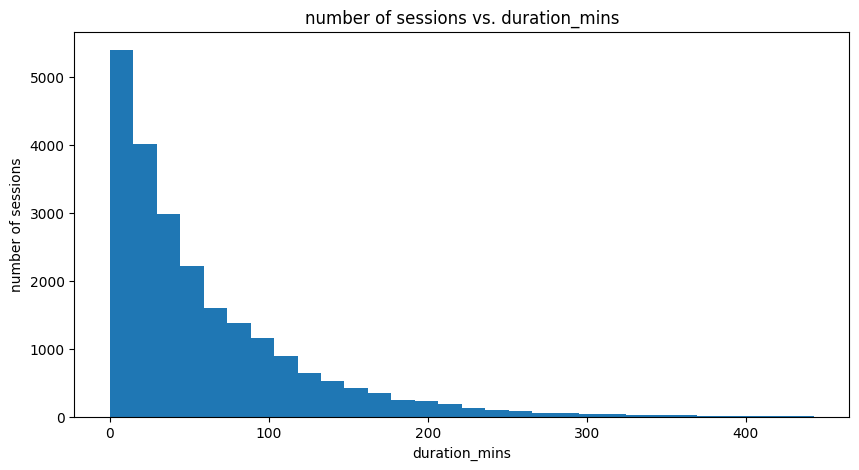

In [89]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["duration_mins"], bins=30)
plt.xlabel("duration_mins")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. duration_mins")

Most viewers tend to watch a stream for a few minutes, and as the duration_mins increases, the number of sessions decreases significantly.

Text(0.5, 1.0, 'number of sessions vs. chat_messages_sent')

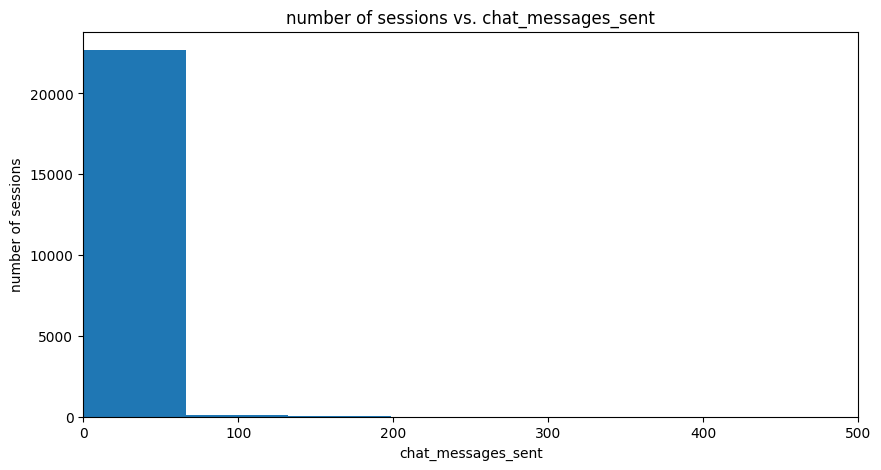

In [90]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["chat_messages_sent"], bins=30)
plt.xlim(0, 500)
plt.xlabel("chat_messages_sent")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. chat_messages_sent")

Most sessions have the number of chat messages that are less than 100. I think this means that viewers do not chat much during sessions. I excluded the data with the most amount of messages sent to see where most of the data is on the x axis. The most amount of chat messages sent is 1987 messages.

Text(0.5, 1.0, 'number of sessions vs. bits_cheered')

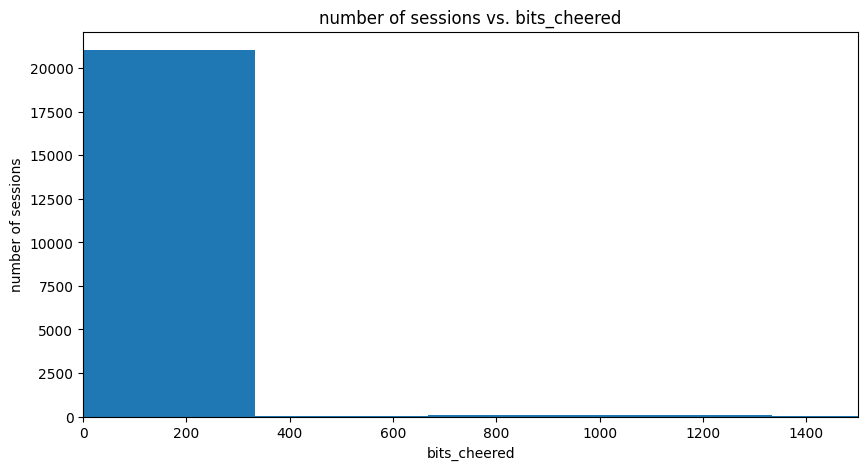

In [91]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["bits_cheered"], bins=30)
plt.xlim(0, 1500)
plt.xlabel("bits_cheered")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. bits_cheered")

This plot of number of sessions vs. bits_cheered has the same shape as the previous plot for number of messages sent. It is a measure of participation. I excluded the outliers same as in the previous plot. The most amount of bits cheered is 10000.

#### Value Ranges

In [92]:
print(
    "Value Range of duration_mins: " +
    str(df_sessions["duration_mins"].min()) +
    "-"  + str(df_sessions["duration_mins"].max())
)

print(
    "Value Range of chat_messages_sent: " +
    str(df_sessions["chat_messages_sent"].min()) +
    "-"  + str(df_sessions["chat_messages_sent"].max())
)

print(
    "Value Range of bits_cheered: " +
    str(df_sessions["bits_cheered"].min()) +
    "-"  + str(df_sessions["bits_cheered"].max())
)

Value Range of duration_mins: 0-443
Value Range of chat_messages_sent: 0-1987
Value Range of bits_cheered: 0-10000


These show the range of values for the columns duration_mins, chat_messages_sent, and bits_cheered.

#### Possible Categories

In [93]:
print("Possible Categories of followed_during: " + str(df_sessions["followed_during"].unique()))
print("Possible Categories of subcribed_during: " + str(df_sessions["subscribed_during"].unique()))

Possible Categories of followed_during: [False  True]
Possible Categories of subcribed_during: [False  True]


Both columns here have boolean values and are therfore categories.

### streamers.csv

*Columns*

- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *streamer_name*: **Unstructured**
    - the name of the streamer (string)
- *category*: **Categorical**
    - the type of streams the streamer does (string)
- *language*: **Categorical**
    - the language used during the streams (string)
- *partner_status*: **Categorical**
    - does the streamer have a partner (boolean)
- *total_followers*: **Numerical**
    - the total amount of followers the streamer has (integer)
- *avg_concurrent_viewers*: **Numerical**
    - average concurrent viewers per stream (integer)

In [94]:
df_streamers.head()

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Checking Type of Boolean Data

In [95]:
print("partner_status type:" + str(df_streamers["partner_status"].dtype))

partner_status type:bool


#### Shape of the Data

Text(0.5, 1.0, 'number of streamers vs. total_followers')

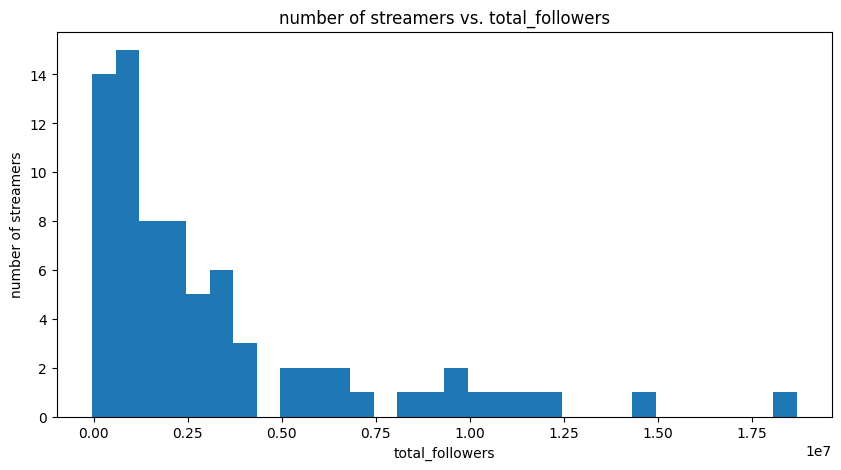

In [96]:
plt.figure(figsize=(10, 5))
plt.hist(df_streamers["total_followers"], bins=30)
plt.xlabel("total_followers")
plt.ylabel("number of streamers")
plt.title("number of streamers vs. total_followers")

This plot has a similar shape to the number of sessions vs. duration_mins plot, but is not continuous. There are a lot of streamers with low follower counts and a few streams with high follower counts.

Text(0.5, 1.0, 'number of streamers vs. avg_concurrent_viewers')

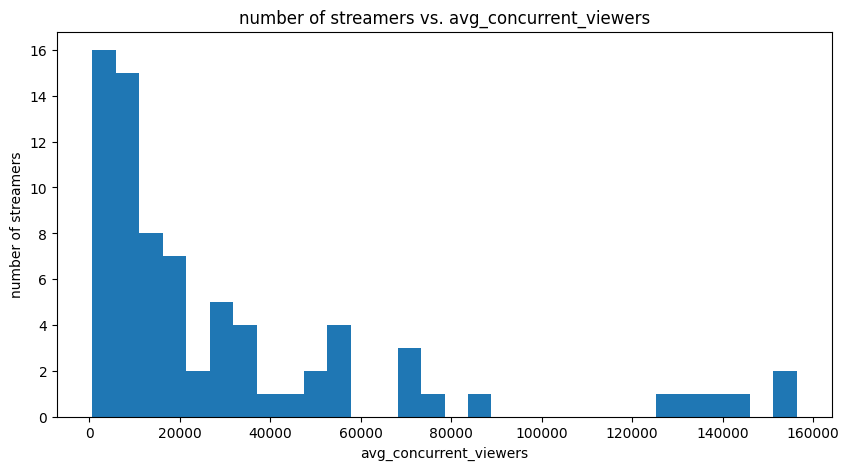

In [97]:
plt.figure(figsize=(10, 5))
plt.hist(df_streamers["avg_concurrent_viewers"], bins=30)
plt.xlabel("avg_concurrent_viewers")
plt.ylabel("number of streamers")
plt.title("number of streamers vs. avg_concurrent_viewers")

This plot has a similar shape to the previous plot and is not continuous. There is a slight increase in average concurrent viewers to the right most of the plot. Most streamers do not have a lot of  concurrent viewers conpared to the right most values.

#### Value Ranges

In [98]:
print(
    "Value Range of total_followers: " +
    str(df_streamers["total_followers"].min()) +
    "-"  + str(df_streamers["total_followers"].max())
)

print(
    "Value Range of avg_concurrent_viewers: " +
    str(df_streamers["avg_concurrent_viewers"].min()) +
    "-"  + str(df_streamers["avg_concurrent_viewers"].max())
)

Value Range of total_followers: -46964-18700000
Value Range of avg_concurrent_viewers: 634-156401


The minimum value for total_followers does not make sense becuase there can not be a nagative amount of folowers. avg_concurrent_viewers' value range makes sense.

#### Possible Categories

In [99]:
print("Possible Categories of category: " + str(df_streamers["category"].unique()))
print("Possible Categories of language: " + str(df_streamers["language"].unique()))
print("Possible Categories of partner_status: " + str(df_streamers["partner_status"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 6, dtype: str
Possible Categories of language: <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str
Possible Categories of partner_status: [ True False]


The categories for the language column has a nan value which needs data cleaning.

### streams.csv

*Columns*

- *stream_id*: **Numerical**
    - the id of the stream (the id starts with SM) (string)
- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *started_at*: **Numerical**
    - the date and time the stream started (year-month-date hour:min:sec format) (string)
- *ended_at*: **Numerical**
    - the date and time the stream ended (year-month-date hour:min:sec format) (string)
- *stream_duration_hrs*: **Numerical**
    - how long the stream lasted in hours (float)
- *category*: **Categorical**
    - the type of stream (string)
- *peak_viewers*: **Numerical**
    - the highest viewer count during the stream (float)
- *title_has_hype_word*: **Categorical**
    - if the title of the stream has the word hype (boolean)
- *was_raid*: **Categorical**
    - of the stream was raided (boolean)

In [100]:
df_streams.head()

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Checking Type of Boolean Data

In [101]:
print("title_has_hype_word type:" + str(df_streams["title_has_hype_word"].dtype))
print("was_raid type:" + str(df_streams["was_raid"].dtype))

title_has_hype_word type:bool
was_raid type:bool


#### Shape of the Data

Text(0.5, 1.0, 'number of streams vs. stream_duration_hrs')

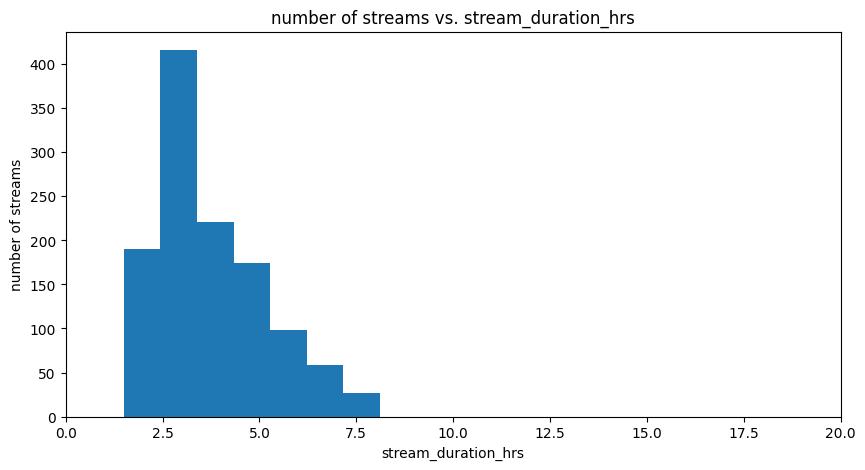

In [102]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["stream_duration_hrs"], bins=100)
plt.xlim(0, 20)
plt.xlabel("stream_duration_hrs")
plt.ylabel("number of streams")
plt.title("number of streams vs. stream_duration_hrs")

There is a peak in the shape of the data. The most anout a streams tend to last a little over 2.5 hours. I excluded the outliers which had high values in stream_duration_hrs so I could view the majority of thed ata in more detail.

Text(0.5, 1.0, 'number of streams vs. peak_viewers')

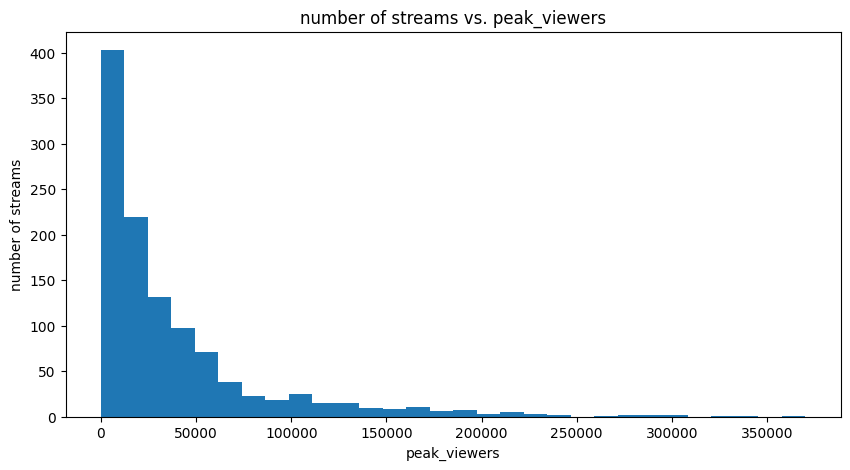

In [103]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["peak_viewers"], bins=30)
plt.xlabel("peak_viewers")
plt.ylabel("number of streams")
plt.title("number of streams vs. peak_viewers")

The shape of this plot decrease signicicantly as peak viewership increases.

#### Value Ranges

In [104]:
print(
    "Value Range of stream_duration_hrs: " +
    str(df_streams["stream_duration_hrs"].min()) +
    "-"  + str(df_streams["stream_duration_hrs"].max())
)

print(
    "Value Range of peak_viewers: " +
    str(df_streams["peak_viewers"].min()) +
    "-"  + str(df_streams["peak_viewers"].max())
)

Value Range of stream_duration_hrs: 1.5-96.0
Value Range of peak_viewers: -50.0-370165.0


stream_duration_hrs' data type of float is appropirate becuase there can be amounts that are fractions of hours. For peak_viewers, there are partial amounts of peak viewers and negative values that need to be cleaned.

#### Possible Categories

In [105]:
print("Possible Categories of category: " + str(df_streams["category"].unique()))
print("Possible Categories of title_has_hype_word: " + str(df_streams["title_has_hype_word"].unique()))
print("Possible Categories of was_raid: " + str(df_streams["was_raid"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str
Possible Categories of title_has_hype_word: [False  True]
Possible Categories of was_raid: [ True False]


category has a nan category which need data cleaning. was_raid's categories are reversed compared to title_has_hype_word. was_raid's True value has a space in front of it. was_raid needs data cleaning.

### viewers.csv

*Columns*

- *viewer_id*: **Numerical**
    - the id of the viewer (the id starts with VWR) (string)
- *age_group*: **Categorical**
    - the age range of the viewer (string)
- *country*: **Categorical**
    - the country the viewer are located in (string)
- *account_age_days*: **Numerical**
    - how on the viewer account is in days (int)
- *subscription_tier*: **Categorical**
    - the subscription tier of the viewer (string)
- *preferred_category*: **Categorical**
    - the type of stream the viewer prefers (string)

In [106]:
df_viewers.head()

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Combining Categories

In [107]:
df_viewers["age_group_formatted"] = df_viewers["age_group"]

mapping = {
    "18–24": "18-24",
    "18 to 24": "18-24",
    "25–34": "25-34",
    "25 to 34": "25-34",
    "35–44": "35-44",
    "35 to 44": "35-44",
}

df_viewers["age_group_formatted"] = df_viewers["age_group_formatted"].replace(mapping)

In [108]:
df_viewers["subscription_tier_formatted"] = df_viewers["subscription_tier"]

mapping = {
    "TIER1": "tier1",
}

df_viewers["subscription_tier_formatted"] = df_viewers["subscription_tier_formatted"].replace(mapping)

There were several same type categories that were written differently. I combined them into a new column.

#### Shape of the Data

Text(0.5, 1.0, 'number of viewers vs. account_age_days')

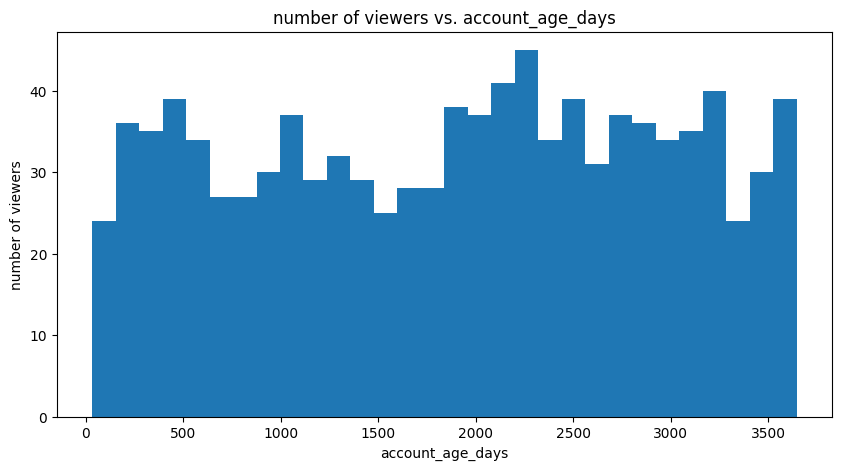

In [109]:
plt.figure(figsize=(10, 5))
plt.hist(df_viewers["account_age_days"], bins=30)
plt.xlabel("account_age_days")
plt.ylabel("number of viewers")
plt.title("number of viewers vs. account_age_days")

There is no shape in the data. There are a diverse and spread out number of viewers who have new and old accounts.

Text(0.5, 1.0, 'number of viewers vs. age_group_formatted')

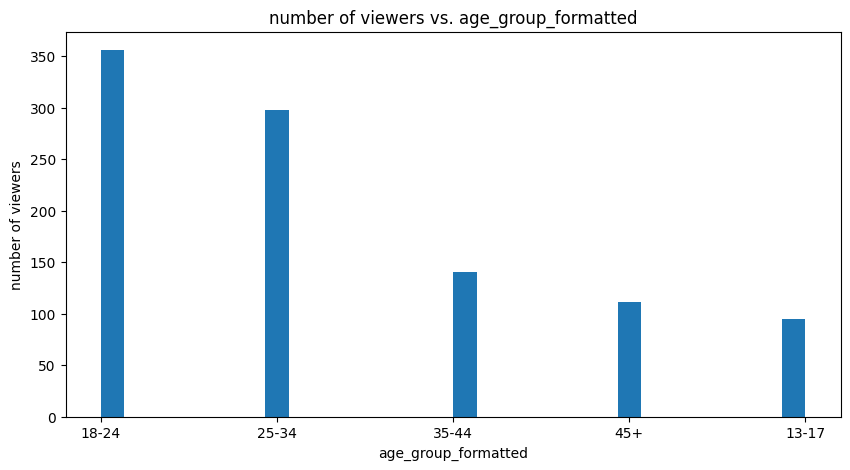

In [110]:
plt.figure(figsize=(10, 5))
plt.hist(df_viewers["age_group_formatted"], bins=30)
plt.xlabel("age_group_formatted")
plt.ylabel("number of viewers")
plt.title("number of viewers vs. age_group_formatted")

Most of the viewers are ages 18-24 and 25-34.

#### Value Ranges

In [111]:
print(
    "Value Range of account_age_days: " +
    str(df_viewers["account_age_days"].min()) +
    "-"  + str(df_viewers["account_age_days"].max())
)

Value Range of account_age_days: 33-3645


The account_age_days value range makes sense.

#### Possible Categories

In [112]:
print("Possible Categories of age_group: " + str(df_viewers["age_group"].unique()))
print("Possible Categories of age_group_formatted: " + str(df_viewers["age_group_formatted"].unique()))
print("Possible Categories of country: " + str(df_viewers["country"].unique()))
print("Possible Categories of subscription_tier: " + str(df_viewers["subscription_tier"].unique()))
print("Possible Categories of subscription_tier_formatted: " + str(df_viewers["subscription_tier_formatted"].unique()))
print("Possible Categories of preferred_category: " + str(df_viewers["preferred_category"].unique()))

Possible Categories of age_group: <StringArray>
[   '18-24',    '25-34',    '35-44',      '45+',    '13-17',    '18–24',
    '25–34', '35 to 44', '18 to 24', '25 to 34',    '35–44']
Length: 11, dtype: str
Possible Categories of age_group_formatted: <StringArray>
['18-24', '25-34', '35-44', '45+', '13-17']
Length: 5, dtype: str
Possible Categories of country: <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str
Possible Categories of subscription_tier: <StringArray>
[      'free',      'tier1',      'tier2',      'tier3', 'free trial',
    'premium',       'none',      'tier4',      'TIER1']
Length: 9, dtype: str
Possible Categories of subscription_tier_formatted: <StringArray>
['free', 'tier1', 'tier2', 'tier3', 'free trial', 'premium', 'none', 'tier4']
Length: 8, dtype: str
Possible Categories of preferred_categ

For age_group, there are categories of 18-24, 25-34, and 35-44 written is in different ways and needs to be cleaned. subscription_tier also needs to be clean because of two ways tier1 is written.

### Task 1 Summary Report

The relationships of each .csv files to the other ones
- sessions point to viewers, streamer, and streams
- streamers do not point to anything
- streams point to streamers
- viewers do not point to anything

There is data cleanup to be done
- nan values need to be removed
- (do in Task 1) inconsistency with the boolean values
- there are some negative values that do not make sense

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


### streamers.csv

In [134]:
df_streamers["total_followers_cleaned"] = df_streamers["total_followers"].map(lambda i: 0 if i < 0 else i)
print(
    "Value Range of total_followers: " +
    str(df_streamers["total_followers"].min()) +
    "-"  + str(df_streamers["total_followers"].max())
)

print(
    "Value Range of total_followers_cleaned: " +
    str(df_streamers["total_followers_cleaned"].min()) +
    "-"  + str(df_streamers["total_followers_cleaned"].max())
)

Value Range of total_followers: -46964-18700000
Value Range of total_followers_cleaned: 0-18700000


I have converted all the negative values of total_followers to 0 because a streamer can not have negative followers.

In [141]:
df_streamers["language_cleaned"] = df_streamers["language"].fillna("other")
print("Possible Categories of language: " + str(df_streamers["language"].unique()))
print("Possible Categories of language_cleaned: " + str(df_streamers["language_cleaned"].unique()))

Possible Categories of language: <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str
Possible Categories of language_cleaned: <StringArray>
['English', 'Spanish', 'other', 'Korean', 'Portuguese']
Length: 5, dtype: str


Converting nan values to other for the language_cleaned column makes more sense because the streamer with nan language values could be speaking a different language that is not listed in this column.

### streams.csv

In [137]:
df_streams["peak_viewers_cleaned"] = df_streams["peak_viewers"].map(lambda i: 0 if i < 0 else i)
print(
    "Value Range of peak_viewers: " +
    str(df_streams["peak_viewers"].min()) +
    "-"  + str(df_streams["peak_viewers"].max())
)

print(
    "Value Range of peak_viewers_cleaned: " +
    str(df_streams["peak_viewers_cleaned"].min()) +
    "-"  + str(df_streams["peak_viewers_cleaned"].max())
)

Value Range of peak_viewers: -50.0-370165.0
Value Range of peak_viewers_cleaned: 0.0-370165.0


I have converted all the negative values of peak_viewers to 0 because a stream can not have negative peak views.

In [140]:
df_streams["category_cleaned"] = df_streams["category"].fillna("other")
print("Possible Categories of category: " + str(df_streams["category"].unique()))
print("Possible Categories of category_cleaned: " + str(df_streams["category_cleaned"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str
Possible Categories of category_cleaned: <StringArray>
['Just Chatting', 'other', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str


Converting nan values to other for the category_cleaned column makes more sense because streams with nan language values could be other categories that are not listed in this column.

### viewers.csv

In [143]:
df_viewers["country_cleaned"] = df_viewers["country"].fillna("other")
print("Possible Categories of country: " + str(df_viewers["country"].unique()))
print("Possible Categories of country_cleaned: " + str(df_viewers["country_cleaned"].unique()))

Possible Categories of country: <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str
Possible Categories of country_cleaned: <StringArray>
[   'AR',    'CA',    'US', 'other',    'DE',    'ES',    'FR',    'GB',
    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',    'JP',
    'IN',    'KR',    'AU',    'TR']
Length: 20, dtype: str


Converting nan values to other for the country_cleaned column makes more sense because the viewers with nan language values could be in a differnt country that is not listed in this column.

### Heuristics

- 
- 
- 

### Task 2 summary report

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

In [114]:
#start code for Task 3 here

### Task 3 Summary report
summarize your findings here. 

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


In [115]:
#start code for Task 4 here

### Task 4 Summary report

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

In [116]:
# tast 5 code starts here

### Task 5 Summary report

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

In [117]:
# task 6 code start here

### Task 6 Summary report

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


In [118]:
# task 7 code start here

### Task 7 Summary report

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  